# Isovalue Specialist: Fixed Intensity Windows + Two-Stage Goal-Blind Selection

Tests `visualization_orchestrator/specialists/isovalue_adapter.py` directly -- no planner, no camera specialist, no `VisualizationOrchestrator` wrapper -- so you can inspect each step in isolation:

1. `compute_fixed_windows` -- split the full intensity range into equal-width windows (deterministic, pure arithmetic -- no file read).
2. Render 6 SEPARATE full-resolution preview images per window (never tiled) in a NEUTRAL GRAYSCALE ramp (`render_window_previews` / `build_evaluation_ramp_for_window`, deterministic) -- not the final warm palette. Each view is labeled only with an opaque id (`view_0`..`view_5`), never front/back/left/right/top/bottom, since the starting camera orientation is arbitrary.
3. `run_isovalue_band_selection` -- a two-stage, GOAL-BLIND pipeline: Stage 1 makes one LLM call PER WINDOW, each call showing all 6 of that window's own (grayscale) views TOGETHER as separate images, with a fully static prompt that never mentions the goal, window name, or intensity range -- just a structured description of visible geometry per view plus a cross-view summary. Stage 2 is ONE text-only call given the goal and every window's stored Stage-1 observation (no images), which selects a winner or abstains (`no_match`). Finally, deterministically derives and applies the FINAL (warm-palette) opacity ramp from the winning window's own range.

This replaced simpler approaches that all turned out unreliable: histogram-band segmentation (only worked when a material formed a genuinely separate histogram peak), self-judged refinement (rarely triggered), and -- most importantly -- letting the LLM see the image AND the goal in the same call, which was confirmed by directly inspecting rendered images to cause goal-conditioned hallucination (e.g. describing a smooth soft-tissue head as "a complete skull... clear anatomical detail"). See the README's "Isovalue specialist" section, "Two-stage goal-blind selection", "Opaque view ids", and "Neutral evaluation color", for the full story with the actual images.

## Setup

Scene initialized. Isovalue=40, dims=(256, 256, 256).


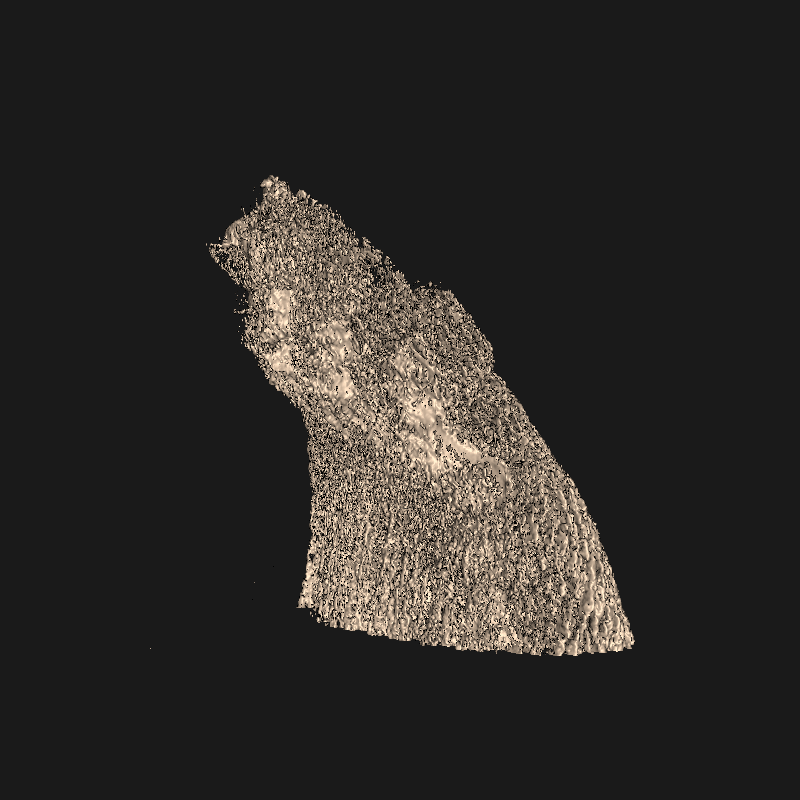

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from camera_reasoning.session import CameraReasoningSession
from visualization_orchestrator.specialists.isovalue_adapter import (
    WINDOW_LABEL_PREFIX,
    build_opacity_ramp_for_band,
    compute_fixed_windows,
    render_window_previews,
    run_isovalue_band_selection,
)

DATASET_PATH = "../data/foot_256x256x256_uint8.raw"
DIMENSIONS = (256, 256, 256)

session = CameraReasoningSession(
    raw_path=DATASET_PATH,
    dimensions=DIMENSIONS,
    isovalue=40,
    output_dir="../output/isovalue_band_demo",
)
session.initialize()
display(Image(filename=session.render_and_save()))

## Step 1: fixed intensity windows (deterministic, no LLM, no file read)

Each window is a `[low, high)` intensity range with one `peak` (just the window's own midpoint -- there's no histogram to find a real peak in). Pure arithmetic: same `num_windows`/`value_range` always gives the same windows, regardless of what the dataset actually contains.

In [2]:
windows = compute_fixed_windows()
for w in windows:
    print(f"[{w['low']:3d}-{w['high']:3d})  peak={w['peak']:3d}")

[  0- 32)  peak= 16
[ 32- 64)  peak= 48
[ 64- 96)  peak= 80
[ 96-128)  peak=112
[128-160)  peak=144
[160-192)  peak=176
[192-224)  peak=208
[224-256)  peak=240


### Visualize the dataset's raw histogram with window boundaries overlaid

Just for context -- the windows themselves don't depend on this at all.

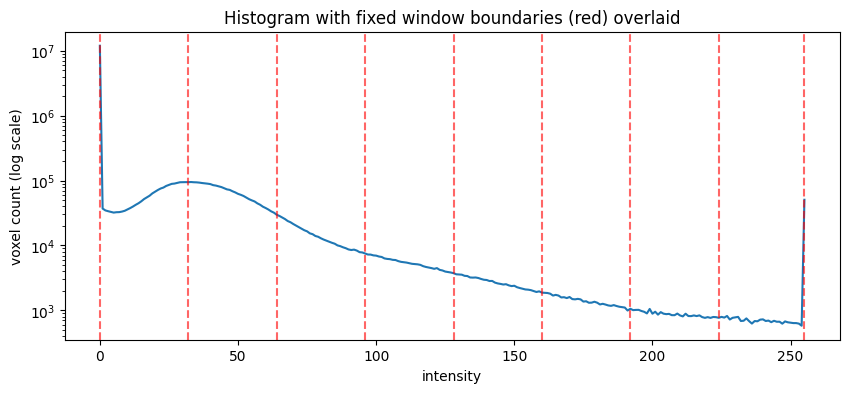

In [3]:
intensities = np.fromfile(DATASET_PATH, dtype=np.uint8)
hist, edges = np.histogram(intensities, bins=256, range=(0, 256))

plt.figure(figsize=(10, 4))
plt.plot(hist)
for w in windows:
    plt.axvline(w["low"], color="red", linestyle="--", alpha=0.6)
plt.axvline(windows[-1]["high"] - 1, color="red", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.xlabel("intensity")
plt.ylabel("voxel count (log scale)")
plt.title("Histogram with fixed window boundaries (red) overlaid")
plt.show()

## Step 2: per-window preview renders (deterministic, no LLM)

6 SEPARATE full-resolution views per window (never combined into a tile), rendered under a NEUTRAL GRAYSCALE ramp (`build_evaluation_ramp_for_window`) -- every window gets the SAME color mapping regardless of its own intensity range, so color can't act as a false "looks like the target material" cue during evaluation. This is what Stage 1's blind observation call sees -- all 6 views sent together in one call, each labeled only `view_0`..`view_5` (opaque, no front/back/left/right/top/bottom -- the starting camera orientation is arbitrary). The FINAL applied result (after Step 3 selects a window) uses a different, warm-palette ramp instead -- see Step 4. `multi_angle=False` here just to keep this cheap/fast (1 view instead of 6); the real pipeline defaults to 6 views per window.

WINDOW_0_32  (opacity ramp peak=16)
  [view_0]


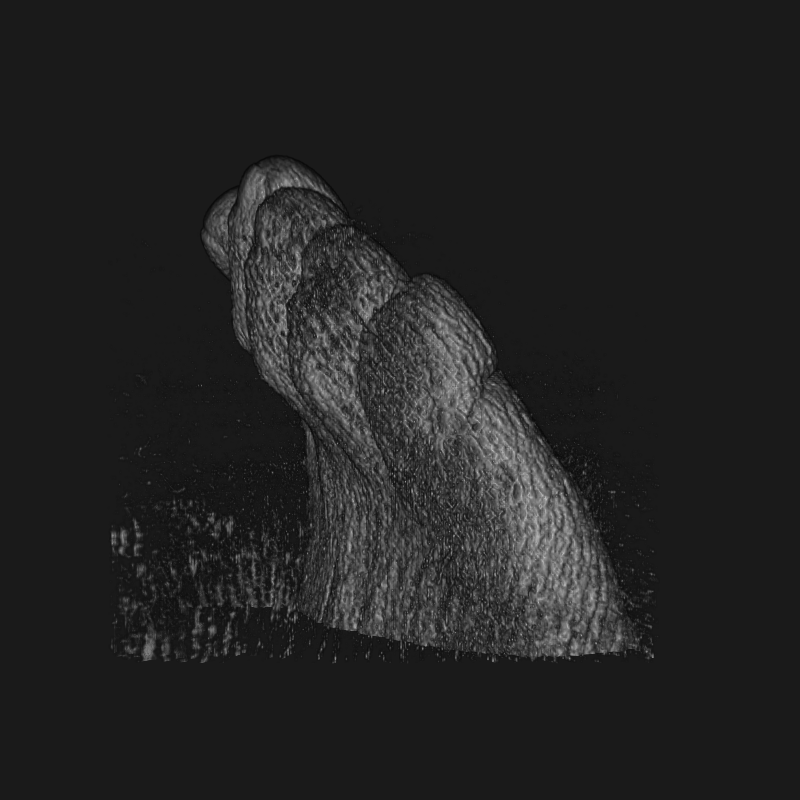

WINDOW_32_64  (opacity ramp peak=48)
  [view_0]


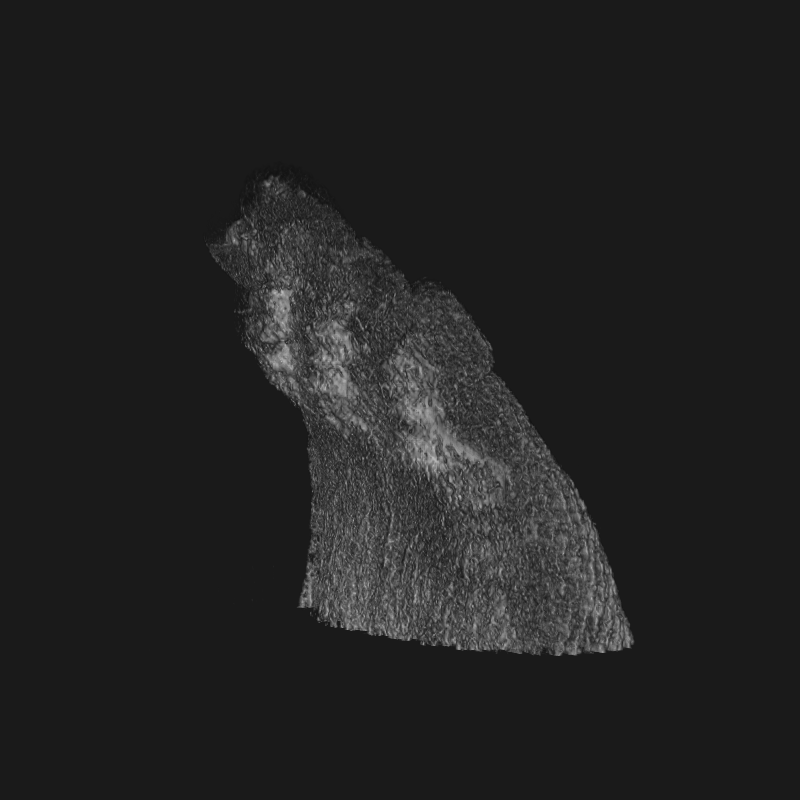

WINDOW_64_96  (opacity ramp peak=80)
  [view_0]


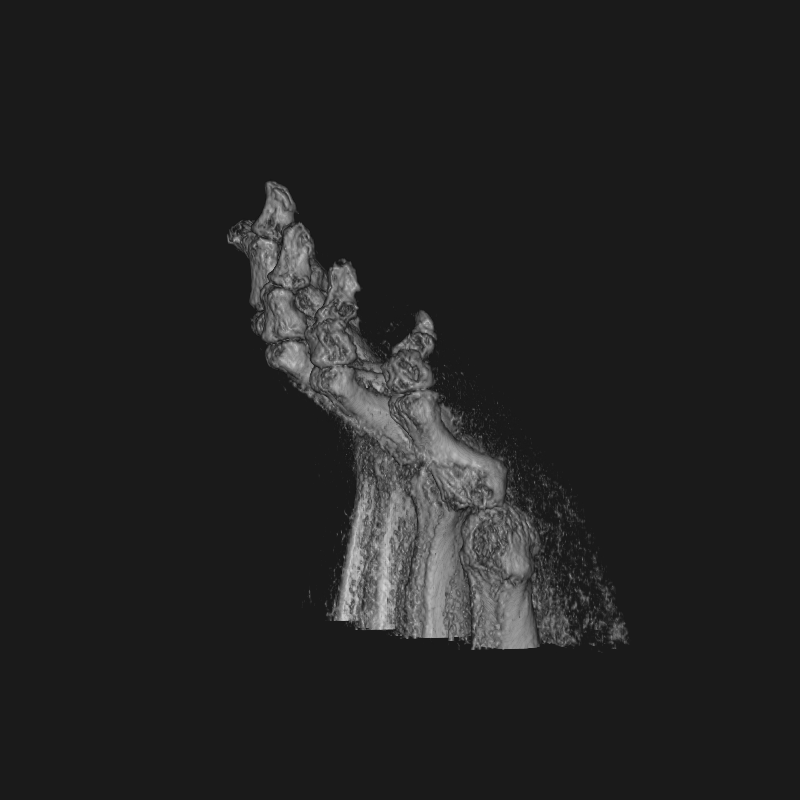

WINDOW_96_128  (opacity ramp peak=112)
  [view_0]


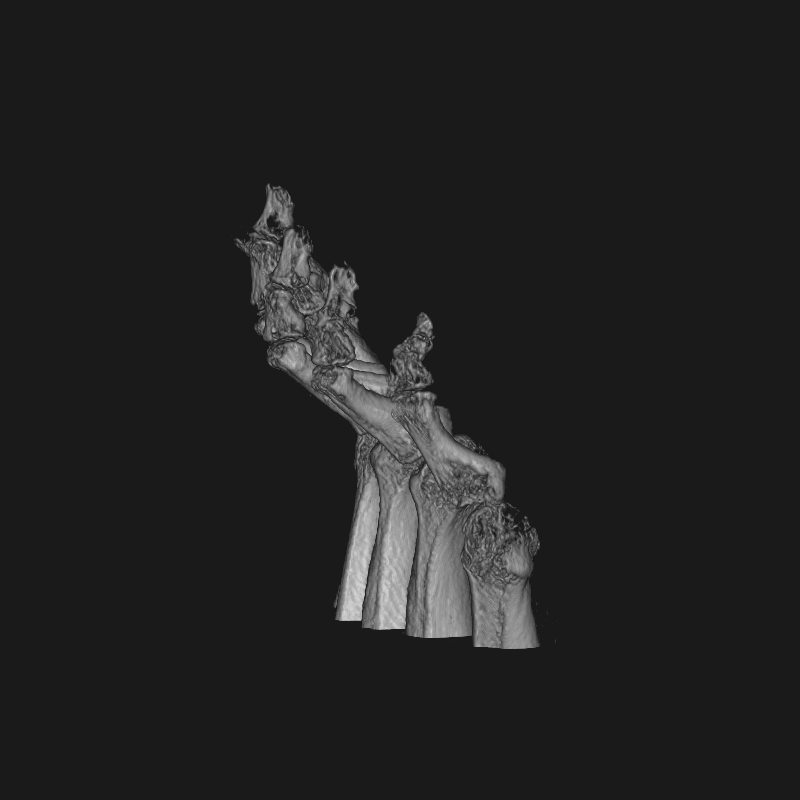

WINDOW_128_160  (opacity ramp peak=144)
  [view_0]


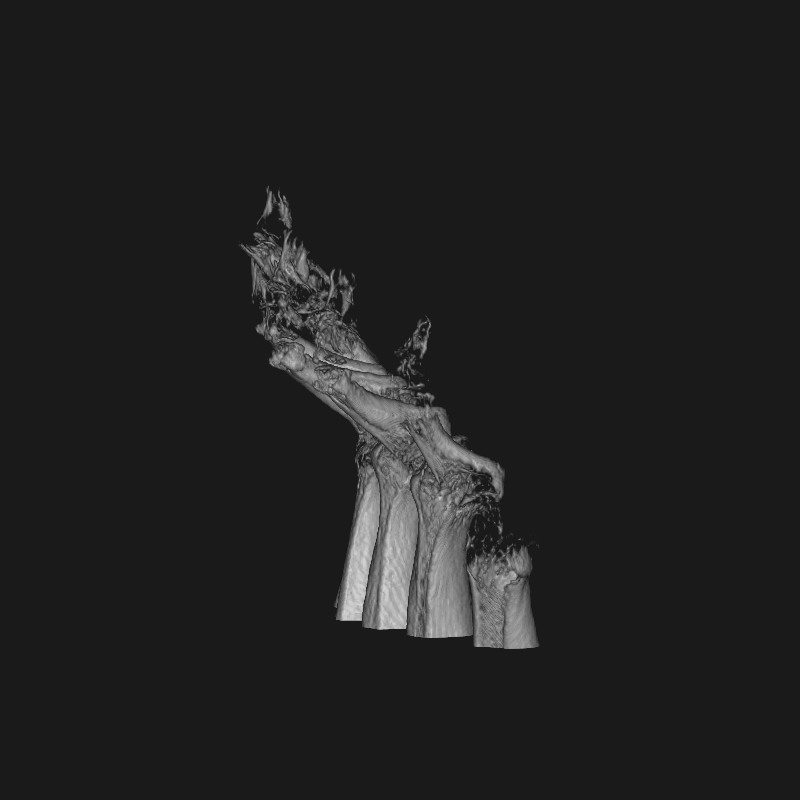

WINDOW_160_192  (opacity ramp peak=176)
  [view_0]


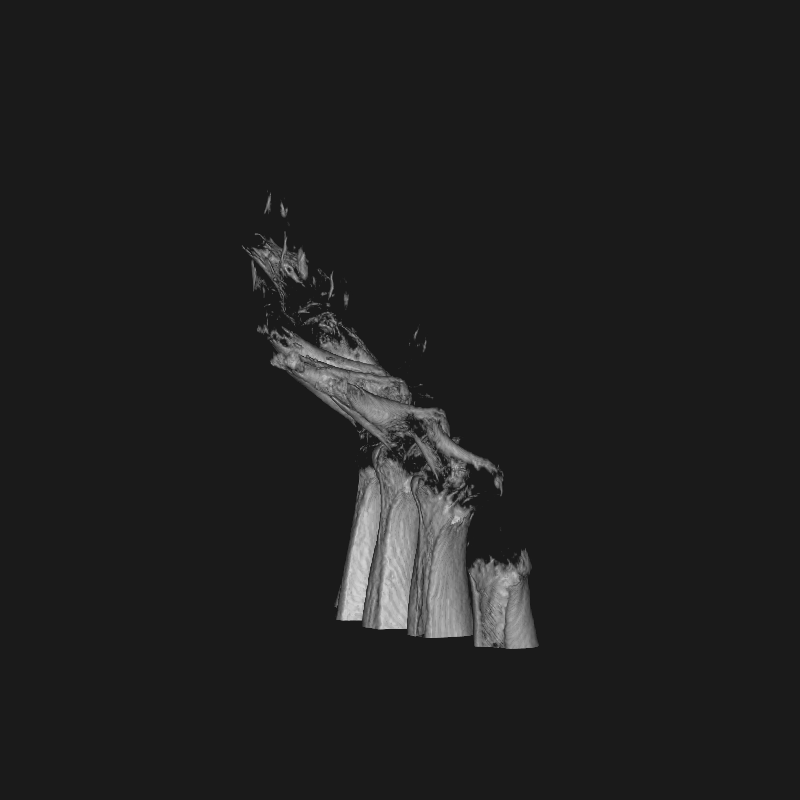

WINDOW_192_224  (opacity ramp peak=208)
  [view_0]


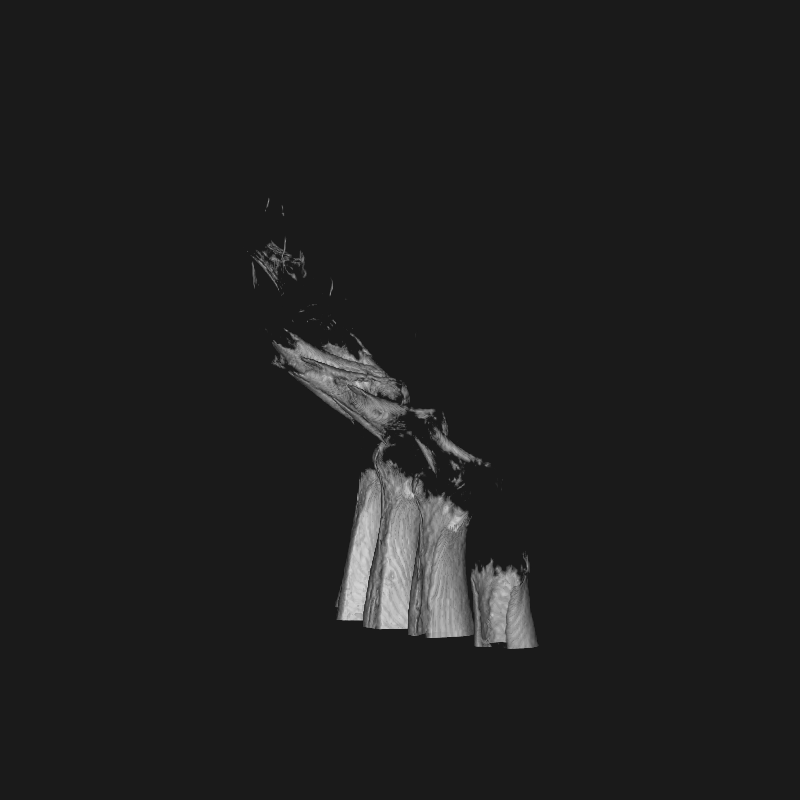

WINDOW_224_256  (opacity ramp peak=240)
  [view_0]


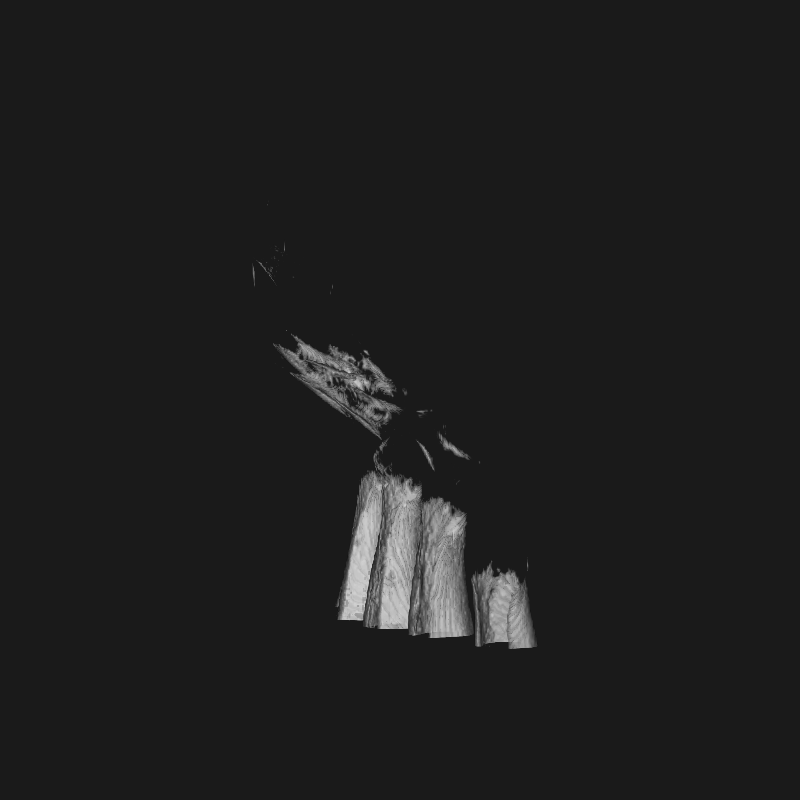

In [4]:
previews = render_window_previews(session, windows, "../output/isovalue_band_demo/previews", multi_angle=False)

for window, view_images in previews:
    print(f"{WINDOW_LABEL_PREFIX}{window['low']}_{window['high']}  (opacity ramp peak={window['peak']})")
    for view_id, path in view_images.items():
        print(f"  [{view_id}]")
        display(Image(filename=path, width=300))


## Step 3: two-stage goal-blind selection

Requires `OPENAI_API_KEY`. Edit `GOAL` below and re-run to try different instructions -- e.g. `"show the bone"`, `"show the soft tissue"`, `"reduce the noise"`. Costs `len(windows) + 1` LLM calls: one blind Stage-1 observation call per window, plus one Stage-2 selection call. `result["band_evaluation"]` holds each window's raw Stage-1 observation (a structured dict -- shape, cavities, fragments, etc. -- not a goal judgment, since Stage 1 never sees the goal at all).

selected_band_label: WINDOW_0_32
converged: True
reasoning: Candidate_0 best satisfies the goal of showing the bone structure. It presents a clearly visible, continuous bone structure with characteristic features: bulbous protrusions arranged in a row (consistent with bone condyles or articular surfaces), deep grooves separating them, and a supporting cylindrical body - all typical anatomical features of bone. Most importantly, it shows minimal fragmentation with a continuous outer surface across all views. While moderate noise fragments exist at edges, the bone structure itself remains clear and intact. In contrast, candidates 2-7 show high fragmentation with multiple disconnected pieces and scattered fragments, failing the 'minimal noise or fragmentation' criterion. Candidate_1 has excessive fiber-like surface texture and moderate surface noise that obscures bone structure clarity. Candidate_0 provides the clearest, most complete bone visualization with minimal disruption.

[WINDOW_0

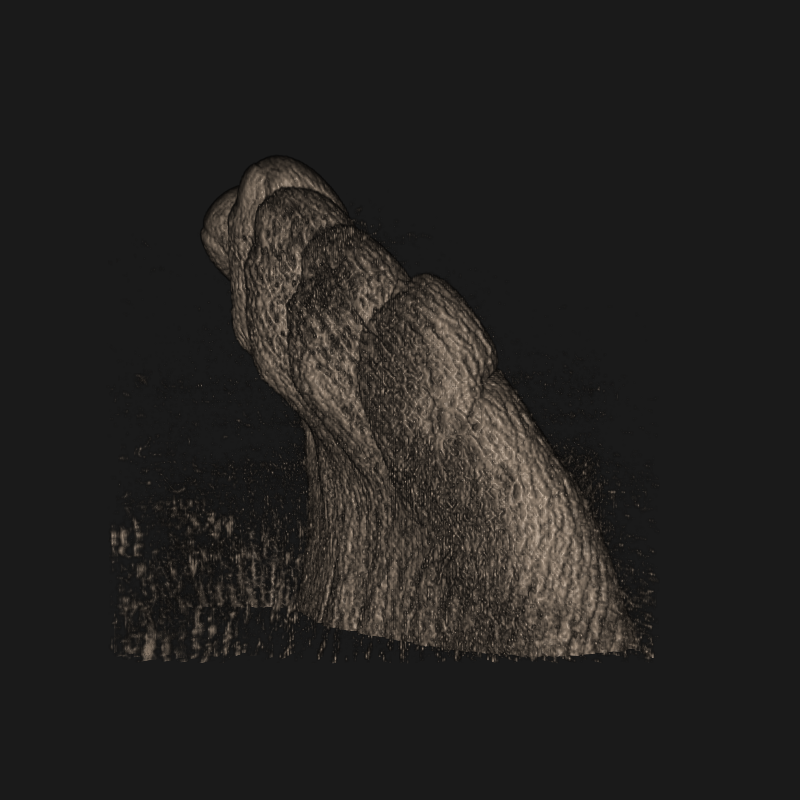

In [5]:
GOAL = "show the bone"
SUCCESS_CRITERIA = ["bone structure is clearly visible", "minimal noise or fragmentation"]

result = run_isovalue_band_selection(session, goal=GOAL, success_criteria=SUCCESS_CRITERIA)

print(f"selected_band_label: {result['selected_band_label']}")
print(f"converged: {result['converged']}")
print(f"reasoning: {result['reasoning']}")
print()
for entry in result["band_evaluation"]:
    print(f"[{entry.get('window')}]")
    print(json.dumps(entry.get('observation'), indent=2))

display(Image(filename=result["final_image_path"]))

## Step 4: inspect the derived opacity ramp (deterministic, no LLM)

The selected band's own `[low, high, peak]` -- not hand-tuned constants -- determine these control points. See `build_opacity_ramp_for_band` in `isovalue_adapter.py`.

opacity_points: [(0.0, 0.0), (16, 0.55), (32, 0.7), (256.0, 0.7)]
color_points: [(0.0, 0.0, 0.0, 0.0), (16, 0.85, 0.75, 0.65), (256.0, 0.85, 0.75, 0.65)]


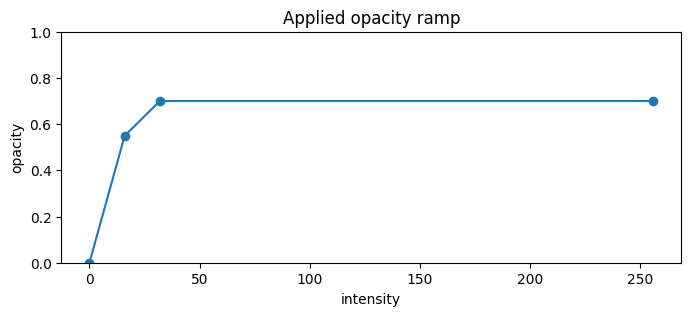

In [6]:
print("opacity_points:", result["final_opacity_points"])
print("color_points:", result["final_color_points"])

if result["final_opacity_points"]:
    xs, ys = zip(*result["final_opacity_points"])
    plt.figure(figsize=(8, 3))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("intensity")
    plt.ylabel("opacity")
    plt.title("Applied opacity ramp")
    plt.ylim(0, 1)
    plt.show()

## Try a different window directly (no LLM, no goal -- just pick one from Step 1's list by index)

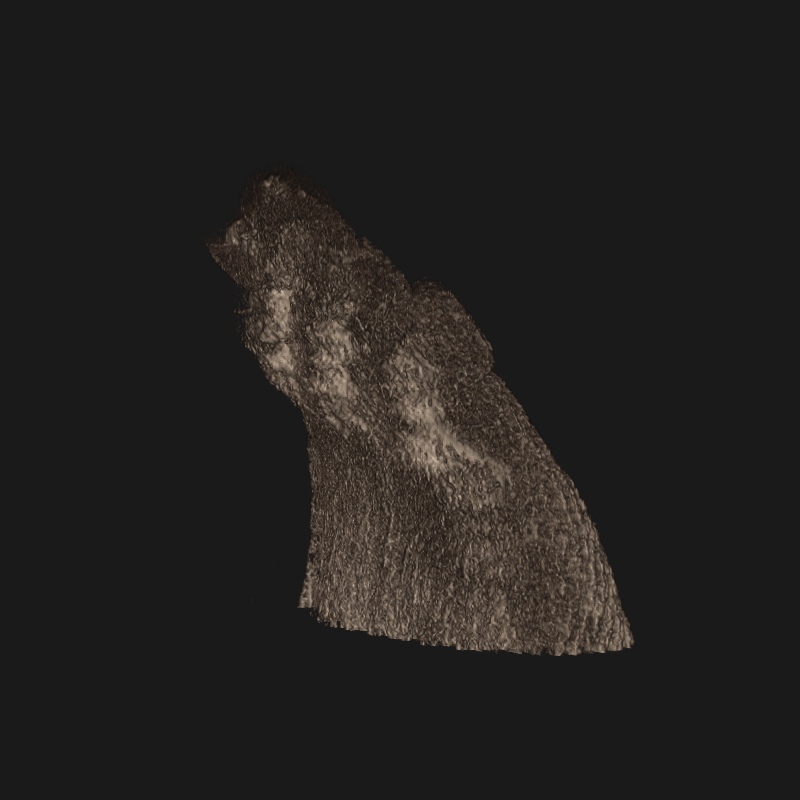

In [7]:
WINDOW_INDEX = 1  # pick any index from Step 1's printed list

chosen_window = windows[WINDOW_INDEX]
opacity_points, color_points = build_opacity_ramp_for_band(chosen_window)
session.set_transfer_function(opacity_points, color_points)
display(Image(filename=session.render_and_save()))